In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import json
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/preprocessed_data.csv', parse_dates=['datetime'])

with open('../data/zscore_results.json', 'r') as f:
    zscore_results = json.load(f)

with open('../data/arima_results.json', 'r') as f:
    arima_results = json.load(f)

print("Data loaded successfully")
print(f"Rows: {len(df)}")
print(f"\nZ-score results: {zscore_results}")
print(f"\nARIMA results: {arima_results}")

Data loaded successfully
Rows: 44534

Z-score results: {'method': 'Z-score', 'threshold': 0.5, 'precision': 0.2756, 'recall': 0.9998, 'f1': 0.4321, 'total_detected': 44520, 'true_positives': 12270, 'false_positives': 32250, 'false_negatives': 2, 'true_negatives': 12}

ARIMA results: {'method': 'ARIMA', 'order': '(1,1,1)', 'sensor': 'Volume Flow RateRMS', 'window_size': 2000, 'refit_every': 200, 'precision': 0.4838, 'recall': 0.2743, 'f1': 0.3501, 'total_detected': 6958, 'true_positives': 3366, 'false_positives': 3592, 'false_negatives': 8906, 'true_negatives': 28670}


In [9]:
comparison_data = {
    'Metric': ['Precision', 'Recall', 'F1 Score',
                'True Positives', 'False Positives',
                'False Negatives', 'True Negatives',
                'Total Detected'],
    'Z-score': [
        zscore_results['precision'],
        zscore_results['recall'],
        zscore_results['f1'],
        zscore_results['true_positives'],
        zscore_results['false_positives'],
        zscore_results['false_negatives'],
        zscore_results['true_negatives'],
        zscore_results['total_detected']
    ],
    'ARIMA': [
        arima_results['precision'],
        arima_results['recall'],
        arima_results['f1'],
        arima_results['true_positives'],
        arima_results['false_positives'],
        arima_results['false_negatives'],
        arima_results['true_negatives'],
        arima_results['total_detected']
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("=" * 60)
print("FINAL COMPARISON: Z-SCORE vs ARIMA")
print("=" * 60)
print(comparison_df.to_string(index=False))
print("=" * 60)
print(f"\nTotal actual anomalies: {int(df['anomaly'].sum())}")
print(f"Total normal rows: {int((df['anomaly']==0).sum())}")

FINAL COMPARISON: Z-SCORE vs ARIMA
         Metric    Z-score      ARIMA
      Precision     0.2756     0.4838
         Recall     0.9998     0.2743
       F1 Score     0.4321     0.3501
 True Positives 12270.0000  3366.0000
False Positives 32250.0000  3592.0000
False Negatives     2.0000  8906.0000
 True Negatives    12.0000 28670.0000
 Total Detected 44520.0000  6958.0000

Total actual anomalies: 12272
Total normal rows: 32262


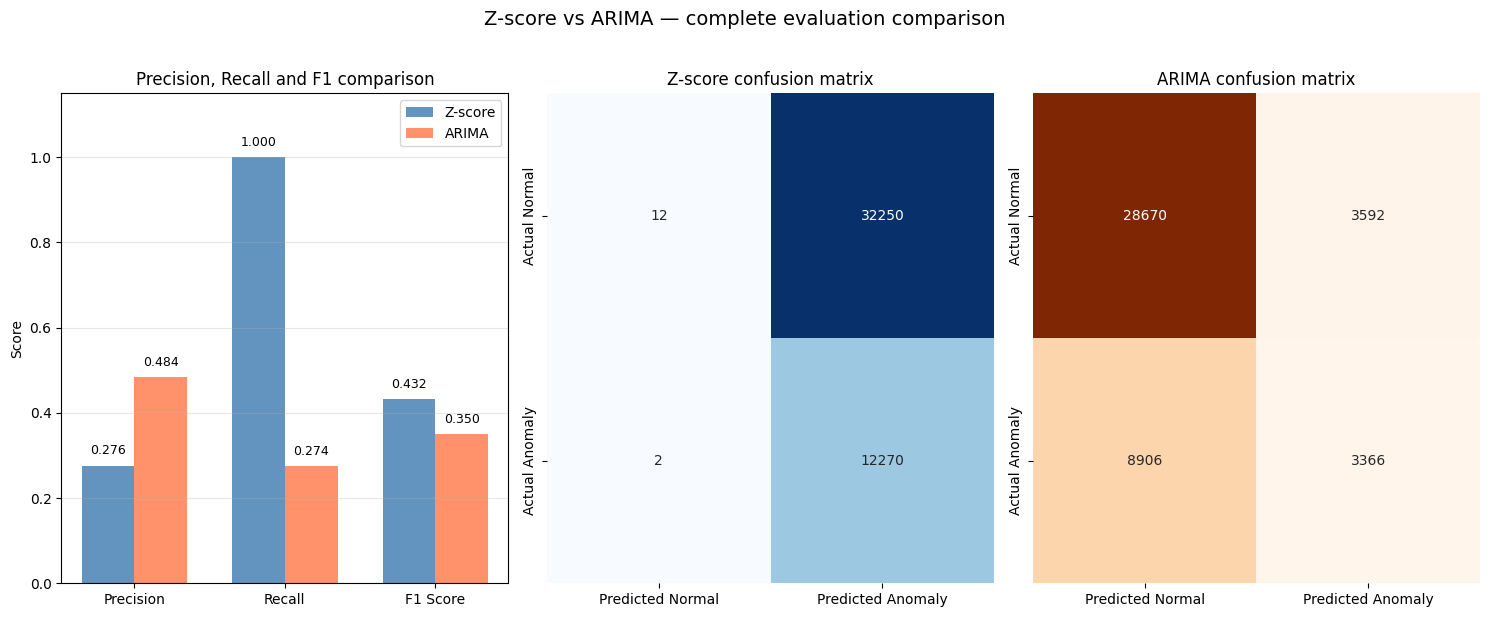

Chart saved


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

metrics = ['Precision', 'Recall', 'F1 Score']
zscore_vals = [zscore_results['precision'],
               zscore_results['recall'],
               zscore_results['f1']]
arima_vals = [arima_results['precision'],
              arima_results['recall'],
              arima_results['f1']]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width/2, zscore_vals, width,
                     label='Z-score', color='steelblue', alpha=0.85)
bars2 = axes[0].bar(x + width/2, arima_vals, width,
                     label='ARIMA', color='coral', alpha=0.85)
axes[0].set_title('Precision, Recall and F1 comparison')
axes[0].set_ylabel('Score')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.15)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=9)

cm_zscore = np.array([[zscore_results['true_negatives'],
                        zscore_results['false_positives']],
                       [zscore_results['false_negatives'],
                        zscore_results['true_positives']]])
sns.heatmap(cm_zscore, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'],
            ax=axes[1], cbar=False)
axes[1].set_title('Z-score confusion matrix')

cm_arima = np.array([[arima_results['true_negatives'],
                       arima_results['false_positives']],
                      [arima_results['false_negatives'],
                       arima_results['true_positives']]])
sns.heatmap(cm_arima, annot=True, fmt='.0f', cmap='Oranges',
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'],
            ax=axes[2], cbar=False)
axes[2].set_title('ARIMA confusion matrix')

plt.suptitle('Z-score vs ARIMA — complete evaluation comparison',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../report/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [11]:
sensor_cols = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current',
               'Pressure', 'Temperature', 'Thermocouple',
               'Voltage', 'Volume Flow RateRMS']

fault_types = ['valve1', 'valve2', 'other']
fault_results = []

for fault in fault_types:
    mask = df['anomaly_source'] == fault
    y_true_fault = df[mask]['anomaly'].astype(int)
    y_pred_zscore_fault = df[mask]['zscore_prediction'].astype(int)
    y_pred_arima_fault = df[mask]['arima_prediction'].astype(int)

    f1_z = f1_score(y_true_fault, y_pred_zscore_fault, zero_division=0)
    f1_a = f1_score(y_true_fault, y_pred_arima_fault, zero_division=0)
    rec_z = recall_score(y_true_fault, y_pred_zscore_fault, zero_division=0)
    rec_a = recall_score(y_true_fault, y_pred_arima_fault, zero_division=0)
    prec_z = precision_score(y_true_fault, y_pred_zscore_fault, zero_division=0)
    prec_a = precision_score(y_true_fault, y_pred_arima_fault, zero_division=0)

    fault_results.append({
        'fault_type': fault,
        'zscore_f1': round(f1_z, 4),
        'arima_f1': round(f1_a, 4),
        'zscore_recall': round(rec_z, 4),
        'arima_recall': round(rec_a, 4),
        'zscore_precision': round(prec_z, 4),
        'arima_precision': round(prec_a, 4)
    })

fault_df = pd.DataFrame(fault_results)
print("Performance by fault type:")
print(fault_df.to_string(index=False))

Performance by fault type:
fault_type  zscore_f1  arima_f1  zscore_recall  arima_recall  zscore_precision  arima_precision
    valve1     0.5155    0.3705         0.9997        0.2585            0.3473           0.6540
    valve2     0.5212    0.3425         1.0000        0.2333            0.3525           0.6437
     other     0.5197    0.3647         1.0000        0.3009            0.3511           0.4629


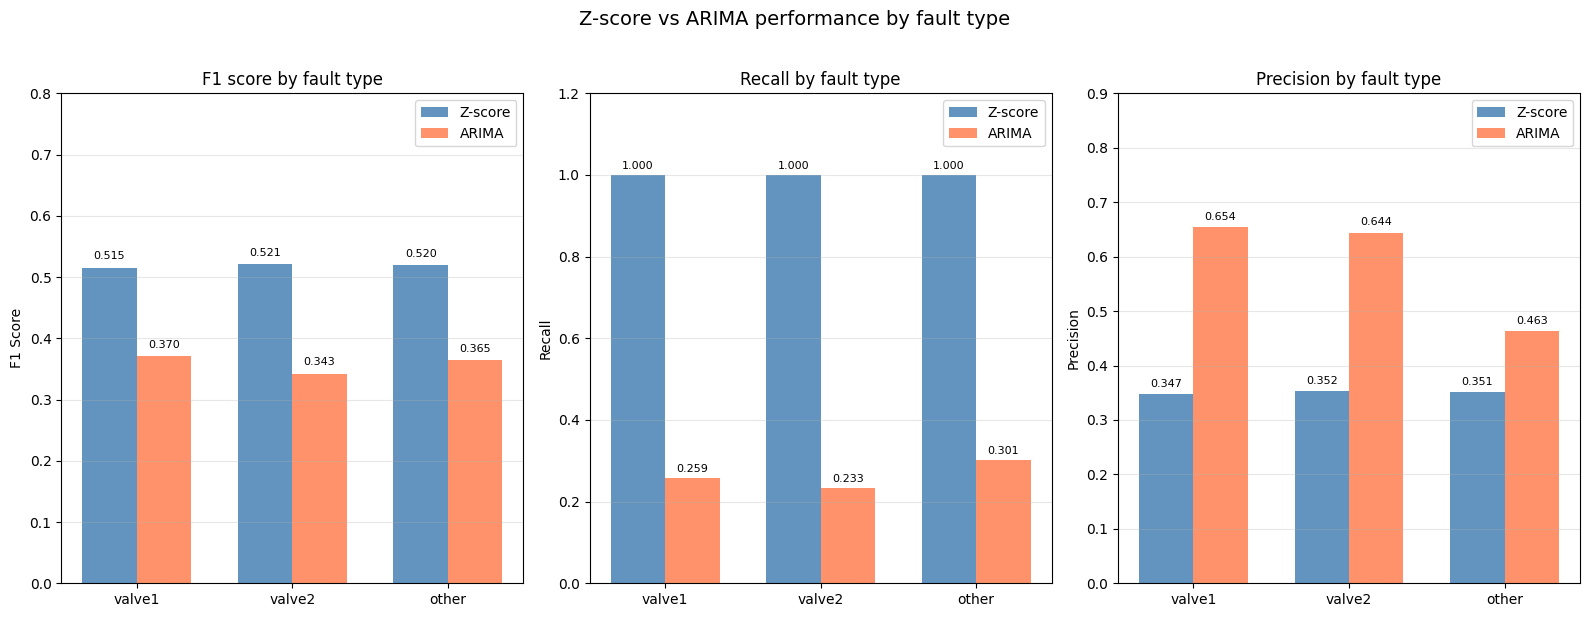

Chart saved


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

x = np.arange(len(fault_types))
width = 0.35

axes[0].bar(x - width/2, fault_df['zscore_f1'],
            width, label='Z-score', color='steelblue', alpha=0.85)
axes[0].bar(x + width/2, fault_df['arima_f1'],
            width, label='ARIMA', color='coral', alpha=0.85)
axes[0].set_title('F1 score by fault type')
axes[0].set_ylabel('F1 Score')
axes[0].set_xticks(x)
axes[0].set_xticklabels(fault_types)
axes[0].set_ylim(0, 0.8)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
for i, (z, a) in enumerate(zip(fault_df['zscore_f1'], fault_df['arima_f1'])):
    axes[0].text(i - width/2, z + 0.01, f'{z:.3f}',
                ha='center', va='bottom', fontsize=8)
    axes[0].text(i + width/2, a + 0.01, f'{a:.3f}',
                ha='center', va='bottom', fontsize=8)

axes[1].bar(x - width/2, fault_df['zscore_recall'],
            width, label='Z-score', color='steelblue', alpha=0.85)
axes[1].bar(x + width/2, fault_df['arima_recall'],
            width, label='ARIMA', color='coral', alpha=0.85)
axes[1].set_title('Recall by fault type')
axes[1].set_ylabel('Recall')
axes[1].set_xticks(x)
axes[1].set_xticklabels(fault_types)
axes[1].set_ylim(0, 1.2)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
for i, (z, a) in enumerate(zip(fault_df['zscore_recall'], fault_df['arima_recall'])):
    axes[1].text(i - width/2, z + 0.01, f'{z:.3f}',
                ha='center', va='bottom', fontsize=8)
    axes[1].text(i + width/2, a + 0.01, f'{a:.3f}',
                ha='center', va='bottom', fontsize=8)

axes[2].bar(x - width/2, fault_df['zscore_precision'],
            width, label='Z-score', color='steelblue', alpha=0.85)
axes[2].bar(x + width/2, fault_df['arima_precision'],
            width, label='ARIMA', color='coral', alpha=0.85)
axes[2].set_title('Precision by fault type')
axes[2].set_ylabel('Precision')
axes[2].set_xticks(x)
axes[2].set_xticklabels(fault_types)
axes[2].set_ylim(0, 0.9)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')
for i, (z, a) in enumerate(zip(fault_df['zscore_precision'], fault_df['arima_precision'])):
    axes[2].text(i - width/2, z + 0.01, f'{z:.3f}',
                ha='center', va='bottom', fontsize=8)
    axes[2].text(i + width/2, a + 0.01, f'{a:.3f}',
                ha='center', va='bottom', fontsize=8)

plt.suptitle('Z-score vs ARIMA performance by fault type',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../report/fault_type_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

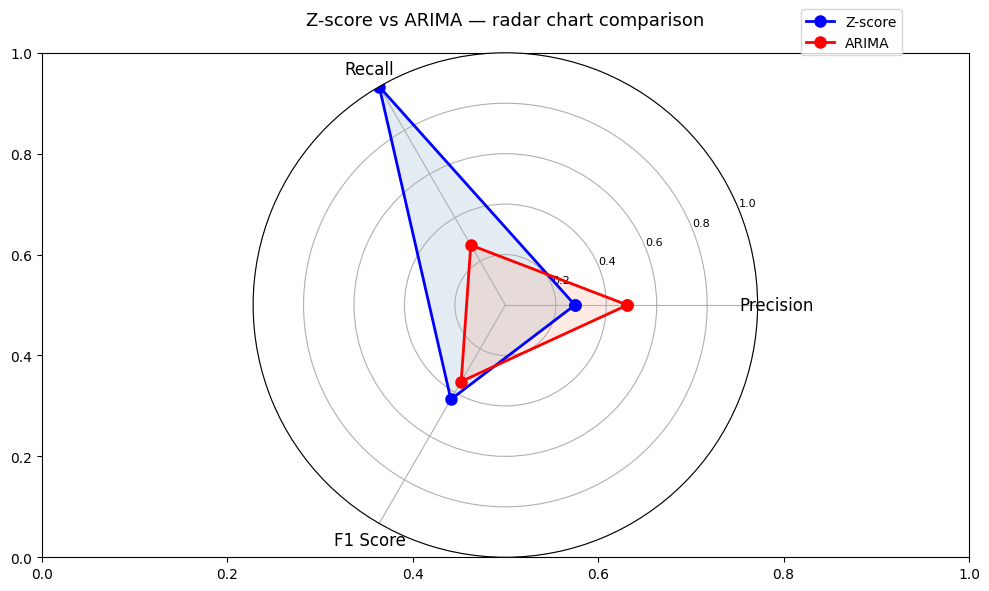

Chart saved


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Precision', 'Recall', 'F1 Score']
zscore_scores = [zscore_results['precision'],
                 zscore_results['recall'],
                 zscore_results['f1']]
arima_scores = [arima_results['precision'],
                arima_results['recall'],
                arima_results['f1']]

angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
zscore_scores_plot = zscore_scores + [zscore_scores[0]]
arima_scores_plot = arima_scores + [arima_scores[0]]
angles += angles[:1]

ax = plt.subplot(111, polar=True)
ax.plot(angles, zscore_scores_plot, 'b-o', linewidth=2,
        markersize=8, label='Z-score')
ax.fill(angles, zscore_scores_plot, alpha=0.15, color='steelblue')
ax.plot(angles, arima_scores_plot, 'r-o', linewidth=2,
        markersize=8, label='ARIMA')
ax.fill(angles, arima_scores_plot, alpha=0.15, color='coral')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.set_title('Z-score vs ARIMA — radar chart comparison',
             fontsize=13, pad=20)

plt.tight_layout()
plt.savefig('../report/radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [14]:
fault_df.to_csv('../data/fault_type_results.csv', index=False)

summary = {
    'dataset': 'SKAB - Skoltech Anomaly Benchmark',
    'total_rows': len(df),
    'total_anomalies': int(df['anomaly'].sum()),
    'total_normal': int((df['anomaly']==0).sum()),
    'anomaly_percentage': round(df['anomaly'].mean() * 100, 2),
    'zscore_best_threshold': zscore_results['threshold'],
    'zscore_precision': zscore_results['precision'],
    'zscore_recall': zscore_results['recall'],
    'zscore_f1': zscore_results['f1'],
    'arima_order': arima_results['order'],
    'arima_sensor': arima_results['sensor'],
    'arima_precision': arima_results['precision'],
    'arima_recall': arima_results['recall'],
    'arima_f1': arima_results['f1'],
    'winner_precision': 'ARIMA',
    'winner_recall': 'Z-score',
    'winner_f1': 'Z-score'
}

with open('../data/project_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

print("All results saved")
print("\nProject summary:")
for key, value in summary.items():
    print(f"  {key}: {value}")

All results saved

Project summary:
  dataset: SKAB - Skoltech Anomaly Benchmark
  total_rows: 44534
  total_anomalies: 12272
  total_normal: 32262
  anomaly_percentage: 27.56
  zscore_best_threshold: 0.5
  zscore_precision: 0.2756
  zscore_recall: 0.9998
  zscore_f1: 0.4321
  arima_order: (1,1,1)
  arima_sensor: Volume Flow RateRMS
  arima_precision: 0.4838
  arima_recall: 0.2743
  arima_f1: 0.3501
  winner_precision: ARIMA
  winner_recall: Z-score
  winner_f1: Z-score
